# Travel Order Resolver

### Installs

The following code notes will require the user to [pip install](https://pip.pypa.io/en/stable/cli/pip_install/):
- pandas
- SpeechRecognition
- transformers
- langdetect
- scikit-learn

### Clarify the provided data

I used this script to both convert Epitech's given SNCF data which was .txt instead of .csv despite having csv data and remove unused columns for future analysis clarity. 

```py
import pandas as pd
import os

remove = {
    'routes.csv': ['route_short_name', 'route_desc', 'route_url', 'route_color', 'route_text_color'],
    'stop_times.csv': ['stop_headsign', 'pickup_type', 'drop_off_type', 'shape_dist_traveled'],
    'stops.csv': ['stop_desc', 'zone_id', 'stop_url', 'location_type'],
    'trips.csv': ['block_id', 'shape_id']
}

for name in os.listdir('./data'):
    if name.endswith('.txt'):
        old_path = os.path.join('./data', name)
        new_name = name.replace('.txt', '.csv')
        new_path = os.path.join('./data', new_name)
        os.rename(old_path, new_path)
        data_frame = pd.read_csv(new_path)
        if new_name in remove:
            data_frame.drop(columns=[col for col in remove[new_name] if col in data_frame.columns], inplace=True)
        data_frame.to_csv(new_path, index=False)

### Create the training data

Labeled data consisting of multiple ways we thought of to ask for a trip with their sentence type (departure or arrival city first) is necessary to fit a model that will recognize the patterns on inputs.

```py
import pandas as pd
import random

patterns = pd.read_csv('./data/patterns.csv', sep='\t')
cities = pd.read_csv('./data/city_station_association.csv', sep='\t')['city'].tolist()
def generate_sentences(pattern,  num_sentences=100):
    sentences = []
    for _ in range(num_sentences):
        city1, city2 = random.sample(cities, 2)
        sentences.append(pattern.replace('$', city1, 1).replace('$', city2, 1))
    return sentences
results = []
for _, row in patterns.iterrows():
    examples = generate_sentences(row['pattern'])
    for example in examples:
        results.append({'sentence': example, 'sentence_type': row['sentence_type']})
pd.DataFrame(results).to_csv('./data/train_data.csv', sep='\t', index=False)

### Transcribe audio input

Import the [SpeechRecognition](https://pypi.org/project/SpeechRecognition/) library (in pair with [PyAudio](https://pypi.org/project/PyAudio/) for microphone use) to recognize french sentences either from a .wav file or straight from the microphone through Google Speech Recognition binding.\
I can then append it to our NLP input csv.

In [4]:
from speech_recognition import Recognizer, WavFile, Microphone, UnknownValueError, RequestError
import pandas as pd
import os

def transcribe_audio(wav_path=None):
    recognizer = Recognizer()
    if wav_path:
        print(f"Recording {wav_path}")
        with WavFile(wav_path) as source:
            audio = recognizer.record(source)
    else:
        print("Using microphone")
        with Microphone() as source:
            print("Adjusting for ambient noise...")
            recognizer.adjust_for_ambient_noise(source)
            print("Listening...")
            audio = recognizer.listen(source)
    try:
        output = recognizer.recognize_google(audio, language="fr-FR")
        print(f"Transcription: {output}")
        return output
    except UnknownValueError:
        print("Google Speech Recognition could not understand audio")
    except RequestError as e:
        print("Could not request results from Google Speech Recognition service; {0}".format(e))

def append_to_csv(transcription, csv_path='./nlp_input.csv'):
    print(f"Opening/creating {csv_path}")
    data_frame = pd.read_csv(csv_path, sep='\t', header=None, names=["sentenceID", "sentence"]) if os.path.exists(csv_path) else pd.DataFrame(columns=["sentenceID", "sentence"])
    new_row = pd.DataFrame([[len(data_frame) + 1, transcription]], columns=["sentenceID", "sentence"])
    data_frame = pd.concat([data_frame, new_row], ignore_index=True)
    data_frame.to_csv(csv_path, sep='\t', header=False, index=False)
    print(f"Successfully saved the transcription !")

append_to_csv(transcribe_audio("./data/human_voice.wav"))

Recording ./data/human_voice.wav
Transcription: je veux aller de Paris à Rennes
Opening/creating ./nlp_input.csv
Successfully saved the transcription !


### Extract departure and arrival

#### Imports

1. **`transformers` (pipeline)**:
   - Enables access to pre-trained [HuggingFace](https://huggingface.co/) transformer models through their pipeline.

2. **`pandas` (read_csv, DataFrame)**:
   - Facilitates data manipulation and analysis, with `read_csv` to load data from CSV files and `DataFrame` for structured data storage.

3. **`langdetect` (detect)**:
   - Detects the language of a given text using probabilistic models trained on multiple languages.
   It is a direct port of Google's [language-detection](https://github.com/shuyo/language-detection) library from Java to Python.

4. **`re` (search, escape)**:
   - Provides tools for matching patterns and escaping special characters in strings using regular expressions.

5. **`CountVectorizer`**:
   - `CountVectorizer` is a feature extraction tool that converts a collection of text documents into a matrix of token counts.
   It tokenizes the text, builds a vocabulary of known words, and encodes new documents by counting occurrences of each word in the vocabulary.
   This is commonly used in text analysis, document classification, and information retrieval tasks, as it provides the basis for creating models by representing text data as numerical vectors.

6. **`TfidfTransformer`**:
   - `TfidfTransformer` is used to transform the token count matrix generated by `CountVectorizer` into a TF-IDF (Term Frequency-Inverse Document Frequency) representation.
   TF-IDF adjusts the raw word counts to reflect the importance of each word in the corpus by penalizing commonly used words and highlighting words that are more unique to a document.
   This normalization improves the performance of models by reducing the bias towards frequently occurring but less informative words, making it a popular technique in text mining and natural language processing tasks.
   NOTE: In many cases, CountVectorizer alone provides enough differentiation for Naive Bayes models, especially for tasks like classification based on keyword patterns, where raw term frequencies (counts) are sufficient. I therefore commented it out for now.

7. **`MultinomialNB`**:
   - `MultinomialNB` is a probabilistic classifier based on the [Naive Bayes](https://en.wikipedia.org/wiki/Naive_Bayes_classifier) theorem, commonly used for text classification tasks where features represent discrete counts, such as word occurrences in documents.
   It works by calculating the conditional probability of each class given the feature set and selecting the class with the highest probability.
   When used with `TfidfTransformer`, the classifier can operate on TF-IDF features instead of raw word counts.
   This improves the model's ability to handle the importance of rare but meaningful words while down-weighting frequent but less informative ones, making it particularly effective in tasks like document classification, spam filtering, and sentiment analysis.

8. **`joblib` (load, dump)**:
   - `joblib` is a library for efficiently saving and loading Python objects, particularly useful for serializing large datasets and machine learning models. It provides the dump function to write objects to disk and the load function to read objects back into memory. This is especially advantageous in machine learning workflows, where trained models need to be saved after training and later retrieved for inference, allowing for quick and efficient model deployment without the need to retrain.

9. **`os` (path.exists)**:
   - `os` is a standard library in Python that provides a way of using operating system-dependent functionality like reading or writing to the file system. The os.path.exists function checks whether a specified path exists or not, which is useful for managing files and directories in your application. This is particularly relevant in data science and machine learning projects for validating the existence of data files or model checkpoints before loading them, thereby ensuring that the necessary resources are available before executing further operations.

10. **`sklearn.metrics` (accuracy_score, classification_report, confusion_matrix)**:
    - `sklearn.metrics` provides a suite of functions to evaluate the performance of machine learning models. The accuracy_score function calculates the proportion of correctly predicted instances out of the total instances. The classification_report function generates a detailed report showing precision, recall, and F1-score for each class, offering insights into the model's performance across different categories. The confusion_matrix function visualizes the performance of a classification algorithm by displaying the number of true positives, false positives, true negatives, and false negatives, allowing for a comprehensive assessment of where the model is making mistakes.

11. **`sklearn.model_selection` (train_test_split)**:
    - `sklearn.model_selection` includes tools for splitting datasets into training and testing subsets. The train_test_split function randomly divides the data into training and testing sets based on specified proportions. This is crucial for evaluating model performance, as it ensures that the model is trained on one subset of data and validated on a separate unseen subset, helping to prevent overfitting and providing a more accurate estimate of model performance on new data.

12. **`matplotlib.pyplot` (figure, imshow, colorbar, title, xlabel, ylabel)**:
    - `matplotlib.pyplot` is a plotting library that provides a MATLAB-like interface for creating static, animated, and interactive visualizations in Python. The figure function creates a new figure or activates an existing one for plotting. The imshow function displays an image or matrix data as a 2D color map, allowing for visual interpretation of numerical data. The colorbar function adds a color scale to the plot, helping to understand the mapping between data values and colors. The title, xlabel, and ylabel functions set the title and labels for the x-axis and y-axis, respectively, enhancing the clarity and context of the visualizations for the viewer.

In [2]:
from transformers import pipeline
from pandas import read_csv, DataFrame
from langdetect import detect
from re import search, escape
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from joblib import load, dump
from os import path
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from matplotlib.pyplot import figure, imshow, colorbar, title, xlabel, ylabel

#### Initialization

The large model I use is fine-tuned by [CamemBERT](https://camembert-model.fr/) for the NER ([Name Entity Recognition](https://en.wikipedia.org/wiki/Named-entity_recognition)) task of identifying entities in the French language, more specifically in our case the LOC (LOCation such as cities).\
It was trained by [CATIE](https://huggingface.co/CATIE-AQ) on the concatenated and cleaned [frenchNER_3entities](https://huggingface.co/datasets/CATIE-AQ/frenchNER_3entities) dataset (420,264 rows, of which 346,071 were used for training with 303,722 LOC, 32,951 for validation with 30,279 LOC and 41,242 for testing with 39,195 LOC) and compares well with other similar french NERs.\
It was built using PyTorch with the following hyperparameters:
- learning_rate: 2e-05
- train_batch_size: 8
- eval_batch_size: 8
- seed: 42
- optimizer: Adam with betas=(0.9,0.999) and epsilon=1e-08
- lr_scheduler_type: linear
- num_epochs: 3

which had the following environmental impact (the hardware, runtime, cloud provider, and compute region were utilized to estimate the carbon impact.):
- Hardware Type: A100 PCIe 40/80GB
- Hours used: 4h31min
-Cloud Provider: Private Infrastructure
- Carbon Efficiency (kg/kWh): 0.077 (estimated from electricitymaps for the day of January 12, 2024.)
- Carbon Emitted (Power consumption x Time x Carbon produced based on location of power grid): 0.009 kg eq. CO2

On the hard `train_data.csv` dataset that I have, the [large spacy french model](https://spacy.io/models/fr#fr_core_news_lg) fails to detect both cities 20.69% of the time (because of trick cases like Albert being both a name and city or just cities it doesnt know).\
Meanwhile NERmembert fails only 10.3% of the time, hence why I chose it.\
I then:
- read the train data and supported cities (mapped from SNCF's CSVs) from their CSVs
- if we already have local .joblib saves of feature extraction fit datas, load them
- otherwise print the accuracy score/classification report/confusion matrix to demonstrate the efficiency of the chosen method, fit it to the actual full training_data for use and dump (save) it in .joblib files for later reuse

Accuracy: 0.93
Classification Report:
              precision    recall  f1-score   support

     from_to       0.95      0.92      0.93      3385
     to_from       0.90      0.94      0.92      2695

    accuracy                           0.93      6080
   macro avg       0.93      0.93      0.93      6080
weighted avg       0.93      0.93      0.93      6080



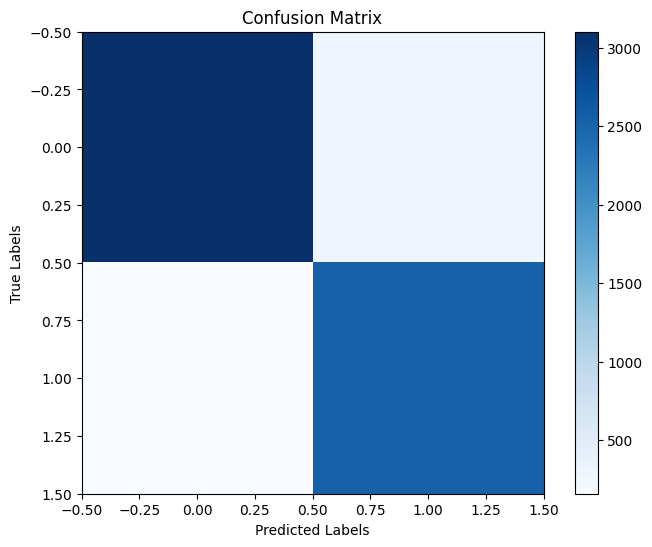

In [3]:
ner = pipeline('token-classification', model='CATIE-AQ/NERmembert-large-3entities', tokenizer='CATIE-AQ/NERmembert-large-3entities', aggregation_strategy="simple")
train_data = read_csv("./data/train_data.csv", sep='\t')
supported_cities = read_csv("./data/city_station_association.csv", sep='\t')['city'].tolist()
files = {
    "count_vectorizer.joblib": CountVectorizer(),
    # "tfidf_transformer.joblib": TfidfTransformer(),
    "multinomial_nb.joblib": MultinomialNB(),
}
if all(path.exists(file) for file in files.keys()):
    for key in files.keys():
        globals()[key.split('.')[0]] = load(key)
else:
    for key in files.keys():
        globals()[key.split('.')[0]] = files[key]

    x_train, x_test, y_train, y_test = train_test_split(
        train_data['sentence'], train_data['sentence_type'], test_size=0.2, random_state=42
    )
    multinomial_nb.fit(count_vectorizer.fit_transform(x_train), y_train) # type: ignore
    y_pred = multinomial_nb.predict(count_vectorizer.transform(x_test)) # type: ignore
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}\nClassification Report:\n{classification_report(y_test, y_pred)}")
    figure(figsize=(8, 6))
    imshow(confusion_matrix(y_test, y_pred), cmap="Blues")
    colorbar()
    title("Confusion Matrix")
    xlabel("Predicted Labels")
    ylabel("True Labels")

    multinomial_nb.fit( # type: ignore
        # tfidf_transformer.fit_transform(  # type: ignore
            count_vectorizer.fit_transform(train_data['sentence']) # type: ignore
        # )
    , train_data['sentence_type'])
    for key in files.keys():
        dump(globals()[key.split('.')[0]], key)


#### Code

Given the path of the nlp_input csv file (for example from the audio transcription code), for each of its rows;
- Read its sentence and sentenceID.
- If none (not a digit) then it'll be refered to as 0 and the output row will contain "NOT_TRIP".
- If the sentence is not french, the output row will contain "NOT_FRENCH".
- Otherwise it's a sentence I can try to get the departure and arrival (in this order) from;
    - Using NERmembert, get all the LOCation entities (cities) of the sentence.
    - Verify they're part of our supported cities (cities that have trip duration data to other cities and can therefore be mapped by a graph algorithm).
    - If it either has less than 2 matched cities (there might be 2 valid cities but they're not both supported) or more (pass-by cities aren't supported yet), return the trip output as "UNKNOWN".
    - If there isn't at least 2 cities detected in the first place, it's "NOT_TRIP".
    - Use the trained classifier to predict the trip order (departure-arrival or arrival-departure) from the sentence's document-term matrix and return the matched cities based on it.

I can then write all the results to nlp_output.csv which can be used by the graph module.

In [4]:
def get_trip(sentence):
    sentence_cities = [entity['word'] for entity in ner(sentence) if entity['entity_group'] == 'LOC']
    matching_cities = [next((c for c in supported_cities if search(rf'\b{escape(c.lower())}\b', s.lower())), None) for s in sentence_cities]
    if None in matching_cities or len(matching_cities) > 2:
        return "UNKNOWN", ""
    if len(sentence_cities) < 2:
        return "NOT_TRIP", ""
    return matching_cities if multinomial_nb.predict(count_vectorizer.transform([sentence]))[0] == "from_to" else matching_cities[::-1] # type: ignore

def get_output(input_path):
    input = read_csv(input_path, header=None, dtype=str, sep='\t')
    rows = []
    for _, row in input.iterrows():
        sentenceID, sentence = row
        sentenceID = int(sentenceID) if sentenceID.isdigit() else 0
        if sentenceID == 0:
            rows.append([sentenceID, "NOT_TRIP", ""])
        elif detect(sentence) != "fr":
            rows.append([sentenceID, "NOT_FRENCH", ""])
        else:
            rows.append([sentenceID, *get_trip(sentence.lower())])
    DataFrame(rows).to_csv("nlp_output.csv", index=False, header=None, sep='\t')

get_output("./nlp_input.csv")